In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# IMPLEMENTACIÓN DEL PERCEPTRÓN DESDE CERO

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=50):
        """
        Inicializa el modelo Perceptrón.

        Parámetros:
        - learning_rate: tasa de aprendizaje
        - epochs: número de iteraciones sobre el dataset
        """
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.errors_per_epoch = []

    def fit(self, X, y):
        """
        Entrena el perceptrón usando aprendizaje supervisado.

        Parámetros:
        - X: matriz de características
        - y: etiquetas reales (-1 y 1)
        """
        n_features = X.shape[1]

        # Inicializar pesos en cero
        # weights[0] = bias
        # weights[1:] = pesos de las características
        self.weights = np.zeros(n_features + 1)
        self.errors_per_epoch = []

        # Entrenamiento por épocas
        for _ in range(self.epochs):
            errors = 0

            for xi, target in zip(X, y):
                prediction = self.predict(xi)

                # Regla de actualización del perceptrón
                update = self.learning_rate * (target - prediction)

                # Ajustar pesos y bias
                self.weights[1:] += update * xi
                self.weights[0] += update

                # Contar error si hubo actualización
                if update != 0.0:
                    errors += 1

            self.errors_per_epoch.append(errors)

        return self

    def net_input(self, X):
        """
        Calcula la combinación lineal:
        w·x + b
        """
        return np.dot(X, self.weights[1:]) + self.weights[0]

    def predict(self, X):
        """
        Función escalón:
        - devuelve 1 si net_input >= 0
        - devuelve -1 si net_input < 0
        """
        return np.where(self.net_input(X) >= 0.0, 1, -1)

In [3]:
# CARGA Y PREPROCESAMIENTO DE DATOS

# Ruta del archivo procesado
file_path = os.path.join("..", "data", "processed", "iris_binario.csv")

# Leer CSV
df = pd.read_csv(file_path)

# Verificar columnas necesarias
required_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"La columna '{col}' no existe en el archivo CSV.")

# Filtrar solo las dos clases binarias
valid_classes = ["Iris-setosa", "Iris-versicolor"]
df = df[df["class"].isin(valid_classes)].copy()

# Verificar que solo existan 2 clases
if df["class"].nunique() != 2:
    raise ValueError("El dataset debe contener exactamente 2 clases.")

# Seleccionar características
X = df[["sepal_length", "petal_length"]].values

# Convertir etiquetas de texto a valores numéricos
# Setosa -> -1
# Versicolor -> 1
y = np.where(df["class"] == "Iris-setosa", -1, 1)

# Ver primeras filas
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# ENTRENAMIENTO DEL MODELO

model = Perceptron(learning_rate=0.1, epochs=10)
model.fit(X, y)

print("Pesos finales:", model.weights)
print("Errores por época:", model.errors_per_epoch)

Pesos finales: [-0.4  -0.68  1.82]
Errores por época: [2, 2, 3, 2, 1, 0, 0, 0, 0, 0]


In [5]:
# PREDICCIONES Y MÉTRICAS

y_pred = model.predict(X)
accuracy = np.mean(y == y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


In [6]:
# GUARDAR RESULTADOS EN CSV

real_labels = np.where(y == -1, "Iris-setosa", "Iris-versicolor")
pred_labels = np.where(y_pred == -1, "Iris-setosa", "Iris-versicolor")
correct = real_labels == pred_labels

results_df = pd.DataFrame({
    "sepal_length": df["sepal_length"].values,
    "petal_length": df["petal_length"].values,
    "real": real_labels,
    "predicha": pred_labels,
    "correcta": correct
})

output_path = os.path.join("..", "data", "processed", "predicciones_perceptron.csv")
results_df.to_csv(output_path, index=False)

print(f"CSV de predicciones guardado en: {output_path}")
results_df.head()

CSV de predicciones guardado en: ../data/processed/predicciones_perceptron.csv


,sepal_length,petal_length,real,predicha,correcta
0,5.1,1.4,Iris-setosa,Iris-setosa,True
1,4.9,1.4,Iris-setosa,Iris-setosa,True
2,4.7,1.3,Iris-setosa,Iris-setosa,True
3,4.6,1.5,Iris-setosa,Iris-setosa,True
4,5.0,1.4,Iris-setosa,Iris-setosa,True


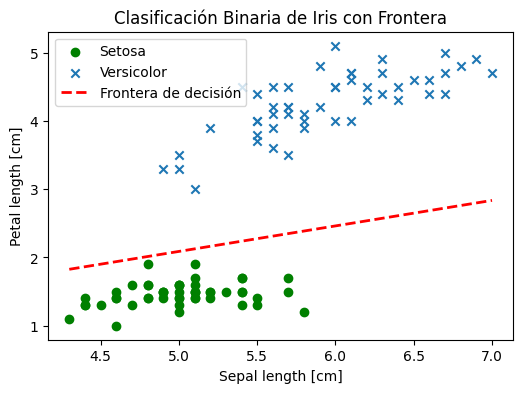

In [7]:
# GRÁFICA DE CLASIFICACIÓN CON FRONTERA DE DECISIÓN

plt.figure(figsize=(6, 4))

# Puntos de cada clase
plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    marker='o',
    label='Setosa',
    color='green'
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker='x',
    label='Versicolor'
)

# LÍNEA DE DECISIÓN 

x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

# Solo si no hay división por cero
if model.weights[2] != 0:
    y_vals = -(model.weights[0] + model.weights[1] * x_vals) / model.weights[2]

    plt.plot(
        x_vals,
        y_vals,
        color="red",
        linewidth=2,
        linestyle="--",
        label="Frontera de decisión"
    )

# 

plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.title('Clasificación Binaria de Iris con Frontera')
plt.legend(loc='upper left')
plt.show()

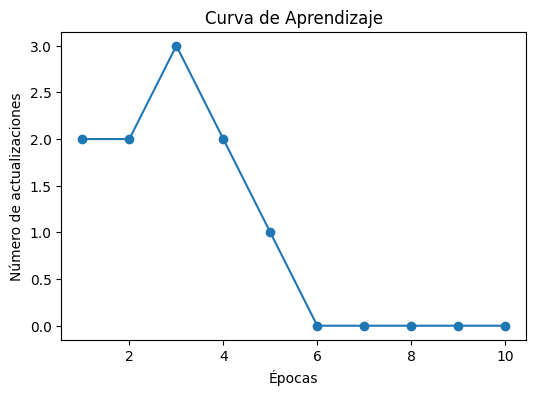

In [8]:

# GRÁFICA 2: CURVA DE APRENDIZAJE


plt.figure(figsize=(6, 4))

plt.plot(
    range(1, len(model.errors_per_epoch) + 1),
    model.errors_per_epoch,
    marker='o'
)

plt.xlabel('Épocas')
plt.ylabel('Número de actualizaciones')
plt.title('Curva de Aprendizaje')
plt.show()

In [9]:
# VER CSV CON PREDICCIONES DEL PERCEPTRÓN
predicciones_df = pd.read_csv(os.path.join("..", "data", "processed", "predicciones_perceptron.csv"))
predicciones_df.head(100)

,sepal_length,petal_length,real,predicha,correcta
0,5.1,1.4,Iris-setosa,Iris-setosa,True
1,4.9,1.4,Iris-setosa,Iris-setosa,True
2,4.7,1.3,Iris-setosa,Iris-setosa,True
3,4.6,1.5,Iris-setosa,Iris-setosa,True
4,5.0,1.4,Iris-setosa,Iris-setosa,True
...,...,...,...,...,...
95,5.7,4.2,Iris-versicolor,Iris-versicolor,True
96,5.7,4.2,Iris-versicolor,Iris-versicolor,True
97,6.2,4.3,Iris-versicolor,Iris-versicolor,True
98,5.1,3.0,Iris-versicolor,Iris-versicolor,True
